# Developing "Momentum" Trading Strategy
--------------------------------------
**Dr. Dave Wanik - University of Connecticut**

Please note that this is not to be taken as financial advice, and that the basis of this notebook was not my original work. I used someone else's notebook to get things started, but then added my own comments, visualizations and exercises to the script to make it more accesible and relevant students.

Now, with that said, let's talk about a really slick application of moving average models and how it can be used in algorithmic trading! 💸 💰 🤑

* Many different takes on this strategy
* Sometimes referred to as trend following
* Whatever you do and call it, you first need to research potential trading signals

# References
This is the link to the original notebook:
* https://github.com/mjmacarty/alphavantage/blob/main/3-momentum_algorithmic.ipynb

And here is the corresponding YouTube video - pay attention to the discussion on 'data leakage' and 'look-ahead' at the end of the video! It's stunning.
* https://www.youtube.com/watch?v=fqltiq5EahU

**Disclaimer:** This should not be taken as financial advice, it is for demonstration purposes and useful as an exercise to test your Python for time series skills.

In [ ]:
# you may need to restart your runtime
# https://stackoverflow.com/questions/68230237/python-pandas-datareader-and-yahoo-error-remotedataerror-unable-to-read-url
!pip install --upgrade pandas
!pip install --upgrade pandas-datareader

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 109 kB 4.4 MB/s 
  Attempting uninstall: pandas-datareader
    Found existing installation: pandas-datareader 0.9.0
    Uninstalling pandas-datareader-0.9.0:
      Successfully uninstalled pandas-datareader-0.9.0


In [ ]:
import numpy as np
import pandas as pd
import pandas_datareader as pdr
import matplotlib.pyplot as plt

### 1. Download data:
* Many services for this, some paid some free
* Yahoo Finance API
* Typically trading "systems" involve a number of securities
* For this demonstration we are just going to look at GLD --> the gold ETF

##### **On your own:** Choose a different variable name besides `gld` - use a different stock besides `gld` - your choice!
Maybe you could call it `myStock`? Update the entire notebook to reflect this change.

You should be able to run the code for any stock even if you just change the first line of code below from `gld = pdr.get_data_yahoo('GLD')` to `gld = pdr.get_data_yahoo('IBM')` or some other stock.

In [ ]:
gld = pdr.get_data_yahoo('GLD')
day = np.arange(1, len(gld) + 1)
gld['day'] = day
gld.drop(columns=['Adj Close', 'Volume'], inplace = True)
gld = gld[['day', 'Open', 'High', 'Low', 'Close']]
gld.head()

,day,Open,High,Low,Close
Date,,,,,
2017-08-18,1,123.370003,123.540001,122.000000,122.300003
2017-08-21,2,122.540001,122.980003,122.500000,122.760002
2017-08-22,3,122.559998,122.559998,121.849998,122.209999
2017-08-23,4,122.580002,122.690002,122.309998,122.669998
2017-08-24,5,122.389999,122.639999,122.129997,122.290001


In [ ]:
# shows the different data types
gld.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2017-08-18 to 2022-08-17
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   day     1258 non-null   int64  
 1   Open    1258 non-null   float64
 2   High    1258 non-null   float64
 3   Low     1258 non-null   float64
 4   Close   1258 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [ ]:
# compute summary statistics of each column
gld.describe()

,day,Open,High,Low,Close
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000
mean,629.500000,148.141884,148.738146,147.480819,148.128247
std,363.297628,23.493623,23.664276,23.258621,23.482361
min,1.000000,111.459999,111.879997,111.059998,111.099998
25%,315.250000,123.805002,124.114998,123.352497,123.687500
50%,629.500000,148.575005,148.955002,147.644997,148.264999
75%,943.750000,169.300003,169.907501,168.607498,169.345005
max,1258.000000,193.740005,194.449997,192.520004,193.889999


In [ ]:
# save a copy of the .csv for use later if we need it
# this has downloaded on the left to your local runtime
gld.to_csv('GLD.csv')

### 2. Add data/transform data
* Calculate a signal based on some price or statistical action
* We are going to try a moving average crossover to generate signals (when two moving averages cross each other)

#### Add moving averages to the data frame

##### **On your own: update the hard-coding of values**
Try something like `upperVal` and `lowerVal` and get rid of the hard-coded 9s and 21s. You should also be careful of any nefarious hard-coded referencing like `[:-252]`... this is also a hard-coded value! Get rid of it!

#### Add a shift of one day to prevent data leakage
As you see at the end YouTube video, if you don't do the shift, you have data leakage on tomorrow's price! You can get a model that looks AMAZING by leaking data - but it won't be amazing when that model does not validate in the real-world.

* `gld['Close'].rolling(9).mean()` includes the 9th day.
* `gld['Close'].rolling(9).mean().shift()` uses the previous 9 day moving average to make its decision for tomorrow's trading day

In [ ]:
# WITH data leakage
# why is it leaking? It includes the 9th day!
gld['9-day'] = gld['Close'].rolling(9).mean()
gld['21-day'] = gld['Close'].rolling(21).mean()
gld.head(n=10)

,day,Open,High,Low,Close,9-day,21-day
Date,,,,,,,
2017-08-18,1,123.370003,123.540001,122.000000,122.300003,NaN,NaN
2017-08-21,2,122.540001,122.980003,122.500000,122.760002,NaN,NaN
2017-08-22,3,122.559998,122.559998,121.849998,122.209999,NaN,NaN
2017-08-23,4,122.580002,122.690002,122.309998,122.669998,NaN,NaN
2017-08-24,5,122.389999,122.639999,122.129997,122.290001,NaN,NaN
2017-08-25,6,122.769997,123.019997,121.290001,122.739998,NaN,NaN
2017-08-28,7,123.330002,124.730003,123.330002,124.690002,NaN,NaN
2017-08-29,8,125.809998,125.870003,124.050003,124.419998,NaN,NaN
2017-08-30,9,124.330002,124.620003,124.160004,124.360001,123.160000,NaN


In [ ]:
# rolled back (no data leakage)
# since this cell is run after, this overwrites the previous data leakage
# you can comment out the cell above and run all if you are nervous!
gld['9-day'] = gld['Close'].rolling(9).mean().shift()
gld['21-day'] = gld['Close'].rolling(21).mean().shift()
gld.head(n=10)

,day,Open,High,Low,Close,9-day,21-day
Date,,,,,,,
2017-08-18,1,123.370003,123.540001,122.000000,122.300003,NaN,NaN
2017-08-21,2,122.540001,122.980003,122.500000,122.760002,NaN,NaN
2017-08-22,3,122.559998,122.559998,121.849998,122.209999,NaN,NaN
2017-08-23,4,122.580002,122.690002,122.309998,122.669998,NaN,NaN
2017-08-24,5,122.389999,122.639999,122.129997,122.290001,NaN,NaN
2017-08-25,6,122.769997,123.019997,121.290001,122.739998,NaN,NaN
2017-08-28,7,123.330002,124.730003,123.330002,124.690002,NaN,NaN
2017-08-29,8,125.809998,125.870003,124.050003,124.419998,NaN,NaN
2017-08-30,9,124.330002,124.620003,124.160004,124.360001,NaN,NaN


## Visualize what the moving averages look like
See where the lines first cross - the 9 day price is dipping below the 21 day price - this means it's time to sell!

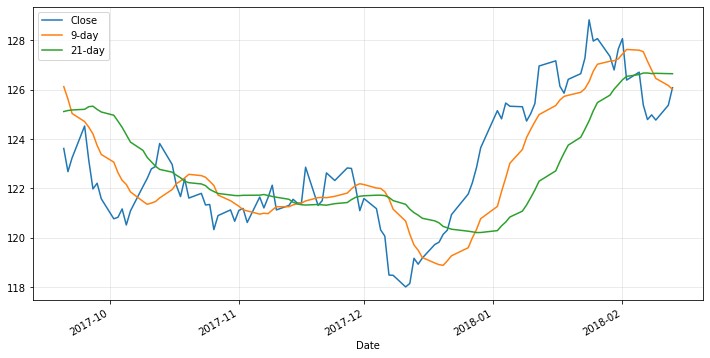

In [ ]:
# imagine where you would put markers on the plot
# for buy vs. sell...

# the 22:123 shows the first 100 days of trading
gld.iloc[22:123,[4,5,6]].plot(figsize=(12,6))
plt.grid(True, alpha = .3)
plt.show()

Did you picture something like this? Below is an embedded picture that I'll show you how to make at the end of the notebook!

## Develop a trading strategy based on moving averages
* When the 9 day price is less than the 21 day price, sell the stock!
* When the 21 day price is greater than the 9 day price, buy the stock!

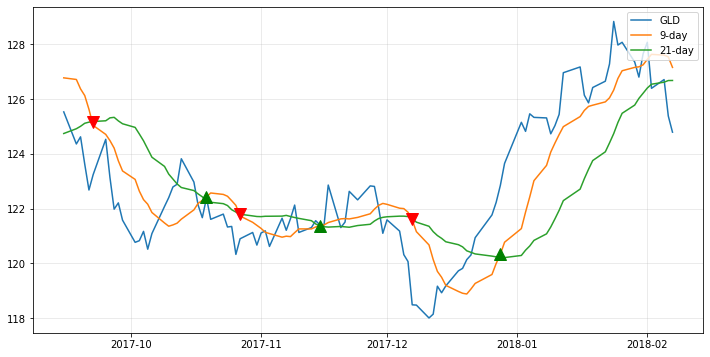

Looking at this first 100 days (after the 21 day warm-up period), we see some really nice trades and  some suboptimal trades. But overall this looks reasonable!

# Create the algorithm

#### Add "signal" column  
The purpose of the column is to show where the moving averages cross each other!

##### **On your own: update the hard-coding of values**
Try something like `upperVal` and `lowerVal` and get rid of the 9s and 21s. You should also be careful of any nefarious hard-coded referencing like `[:-252]`... this is a hard-coded value!

In [ ]:
# the np.where() function is similar to the Excel =IF() statement
gld['signal'] = np.where(gld['9-day'] > gld['21-day'], 1, 0)
gld['signal'] = np.where(gld['9-day'] < gld['21-day'], -1, gld['signal'])
# drop where we don't have any data - notice how the dates in the index are different!
gld.dropna(inplace=True)
gld.head(n=30)

,day,Open,High,Low,Close,9-day,21-day,signal
Date,,,,,,,,
2017-09-19,22,124.489998,124.650002,124.029999,124.620003,126.368890,125.004762,1
2017-09-20,23,124.680000,125.059998,123.150002,123.620003,126.125557,125.115238,1
2017-09-21,24,122.559998,123.070000,122.489998,122.680000,125.624446,125.156191,1
2017-09-22,25,123.029999,123.389999,122.930000,123.239998,125.036668,125.178572,-1
2017-09-25,26,122.779999,124.660004,122.709999,124.529999,124.708889,125.205715,-1
2017-09-26,27,123.570000,123.809998,122.900002,123.139999,124.483334,125.312381,-1
2017-09-27,28,122.040001,122.510002,121.879997,121.980003,124.208889,125.331429,-1
2017-09-28,29,122.040001,122.480003,121.830002,122.209999,123.744445,125.202381,-1
2017-09-29,30,122.290001,122.300003,121.550003,121.580002,123.375556,125.097143,-1


By looking at the tabular data, you can see that we sell on Day 27 because the 9 day average is less than the 21 day average - meaning that there is a downward trend (momentum)!

You can see that we buy on Day 46 because the 9 day average is greater than the 21 day average - meaning that there is an upward trend (momentum)!

#### Calculate Instantaneous returns/system returns
`.diff()` calculates the difference between the current row and previous row. That's why there is a `NaN` at the beginning of the dataframe when we create the `gld['return']` column.

Note that np.log() is actually the natural log!
* https://numpy.org/doc/stable/reference/generated/numpy.log.html

In [ ]:
# the ln of negative numbers is NaN
# ln of 0 is -inf
np.log([-5,-3,-1, -0.5, -0.1, -0.01 ,0])

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in log
  This is separate from the ipykernel package so we can avoid doing imports until


array([ nan,  nan,  nan,  nan,  nan,  nan, -inf])

In [ ]:
# the ln of positive numbers are
np.log([0.01, 0.1, 0.5, 1, 3, 5])

array([-4.60517019, -2.30258509, -0.69314718,  0.        ,  1.09861229,
        1.60943791])

`gld['return']` will be the 'buy and hold' return. And later, we will make a variable for our system, the momentum trading algorithm!

In [ ]:
gld['logClose'] = np.log(gld['Close']) # price will always be positive
gld['return'] = gld['logClose'].diff() # the difference will be positive or negative
gld.head()

,day,Open,High,Low,Close,9-day,21-day,signal,logClose,return
Date,,,,,,,,,,
2017-09-19,22,124.489998,124.650002,124.029999,124.620003,126.368890,125.004762,1,4.825269,NaN
2017-09-20,23,124.680000,125.059998,123.150002,123.620003,126.125557,125.115238,1,4.817212,-0.008057
2017-09-21,24,122.559998,123.070000,122.489998,122.680000,125.624446,125.156191,1,4.809579,-0.007633
2017-09-22,25,123.029999,123.389999,122.930000,123.239998,125.036668,125.178572,-1,4.814134,0.004554
2017-09-25,26,122.779999,124.660004,122.709999,124.529999,124.708889,125.205715,-1,4.824547,0.010413


In [ ]:
# the variable 'return' is just the difference bt current and previous row
# you could also just do this in one line of code
# but two lines makes it easier to see
# gld['return'] = np.log(gld['Close']).diff()


In [ ]:
# The 'system_return' tells you how much money you would have made
# using your momentum trading algorithm!
gld['system_return'] = gld['signal'] * gld['return']
gld.head(n=20)

,day,Open,High,Low,Close,9-day,21-day,signal,logClose,return,system_return
Date,,,,,,,,,,,
2017-09-19,22,124.489998,124.650002,124.029999,124.620003,126.368890,125.004762,1,4.825269,NaN,NaN
2017-09-20,23,124.680000,125.059998,123.150002,123.620003,126.125557,125.115238,1,4.817212,-0.008057,-0.008057
2017-09-21,24,122.559998,123.070000,122.489998,122.680000,125.624446,125.156191,1,4.809579,-0.007633,-0.007633
2017-09-22,25,123.029999,123.389999,122.930000,123.239998,125.036668,125.178572,-1,4.814134,0.004554,-0.004554
2017-09-25,26,122.779999,124.660004,122.709999,124.529999,124.708889,125.205715,-1,4.824547,0.010413,-0.010413
2017-09-26,27,123.570000,123.809998,122.900002,123.139999,124.483334,125.312381,-1,4.813322,-0.011225,0.011225
2017-09-27,28,122.040001,122.510002,121.879997,121.980003,124.208889,125.331429,-1,4.803857,-0.009465,0.009465
2017-09-28,29,122.040001,122.480003,121.830002,122.209999,123.744445,125.202381,-1,4.805741,0.001884,-0.001884
2017-09-29,30,122.290001,122.300003,121.550003,121.580002,123.375556,125.097143,-1,4.800572,-0.005168,0.005168


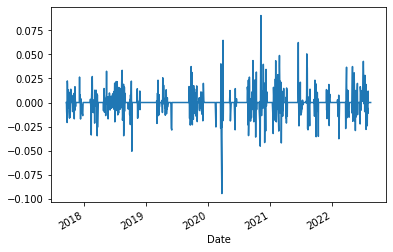

In [ ]:
# numbers look weird? plot them!
(gld['system_return'] - gld['return']).plot()
plt.show()

You can also sum up the returns!

In [ ]:
np.exp(np.sum(gld['return'])) -1

0.3202936931135809

In [ ]:
np.exp(np.sum(gld['system_return'])) -1

0.0897234956650581

This is the tricky part - now we make a column called 'signal' which tells you when you enter and leave the market.

In [ ]:
# the variable entry tells you when you buy and sell
# we will use it to make red and green triangles
gld['entry'] = gld['signal'].diff()
print(gld['entry'].value_counts())

 0.0    1168
-2.0      34
 2.0      34
Name: entry, dtype: int64


Looks like we do nothing 1168 times, we buy 34 times and sell 34 times

In [ ]:
gld.head(n=10) # check your work

,day,Open,High,Low,Close,9-day,21-day,signal,logClose,return,system_return,entry
Date,,,,,,,,,,,,
2017-09-19,22,124.489998,124.650002,124.029999,124.620003,126.368890,125.004762,1,4.825269,NaN,NaN,NaN
2017-09-20,23,124.680000,125.059998,123.150002,123.620003,126.125557,125.115238,1,4.817212,-0.008057,-0.008057,0.0
2017-09-21,24,122.559998,123.070000,122.489998,122.680000,125.624446,125.156191,1,4.809579,-0.007633,-0.007633,0.0
2017-09-22,25,123.029999,123.389999,122.930000,123.239998,125.036668,125.178572,-1,4.814134,0.004554,-0.004554,-2.0
2017-09-25,26,122.779999,124.660004,122.709999,124.529999,124.708889,125.205715,-1,4.824547,0.010413,-0.010413,0.0
2017-09-26,27,123.570000,123.809998,122.900002,123.139999,124.483334,125.312381,-1,4.813322,-0.011225,0.011225,0.0
2017-09-27,28,122.040001,122.510002,121.879997,121.980003,124.208889,125.331429,-1,4.803857,-0.009465,0.009465,0.0
2017-09-28,29,122.040001,122.480003,121.830002,122.209999,123.744445,125.202381,-1,4.805741,0.001884,-0.001884,0.0
2017-09-29,30,122.290001,122.300003,121.550003,121.580002,123.375556,125.097143,-1,4.800572,-0.005168,0.005168,0.0


#### Plot trades on time series

##### **On your own: update the hard-coding of values**
Try something like `upperVal` and `lowerVal` and get rid of the 9s and 21s. You should also be careful of any nefarious hard-coded referencing like `[:-252]`... this is a hard-coded value!

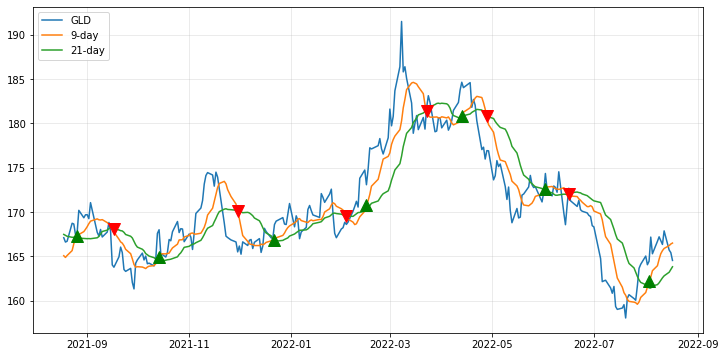

In [ ]:
# show the last year
plt.rcParams['figure.figsize'] = 12, 6
plt.grid(True, alpha = .3)
plt.plot(gld.iloc[-252:]['Close'], label = 'GLD')
plt.plot(gld.iloc[-252:]['9-day'], label = '9-day')
plt.plot(gld.iloc[-252:]['21-day'], label = '21-day')
plt.plot(gld[-252:].loc[gld.entry == 2].index, gld[-252:]['9-day'][gld.entry == 2], '^',
         color = 'g', markersize = 12)
plt.plot(gld[-252:].loc[gld.entry == -2].index, gld[-252:]['21-day'][gld.entry == -2], 'v',
         color = 'r', markersize = 12)
plt.legend(loc=2);

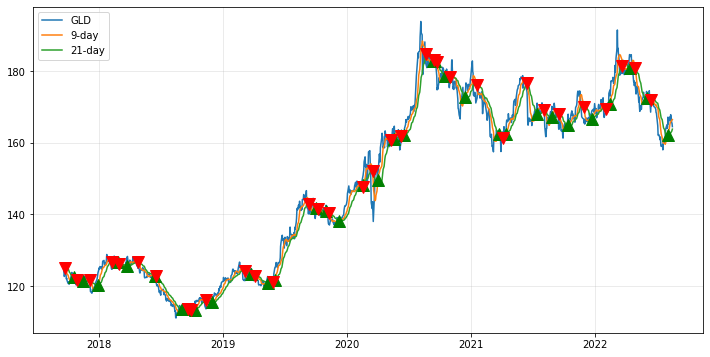

In [ ]:
# show all time
# if you squint closely you should see 34 red triangles
# and 34 green triangles!
plt.rcParams['figure.figsize'] = 12, 6
plt.grid(True, alpha = .3)
plt.plot(gld.iloc[:]['Close'], label = 'GLD')
plt.plot(gld.iloc[:]['9-day'], label = '9-day')
plt.plot(gld.iloc[:]['21-day'], label = '21-day')
plt.plot(gld[:].loc[gld.entry == 2].index, gld[:]['9-day'][gld.entry == 2], '^',
         color = 'g', markersize = 12)
plt.plot(gld[:].loc[gld.entry == -2].index, gld[:]['21-day'][gld.entry == -2], 'v',
         color = 'r', markersize = 12)
plt.legend(loc=2);

Let's see how your portfolio would have done!

In [ ]:
# adding a few steps here for clarity
# 'r' is for return (buy and hold)
gld['r_cumprod'] = np.exp(gld['return'])
gld['exp_r_cumprod'] = gld['r_cumprod'].cumprod()

# 's' is for system (algo trading!)
gld['s_cumprod'] = np.exp(gld['system_return'])
gld['exp_s_cumprod'] = gld['s_cumprod'].cumprod()
gld.head()

,day,Open,High,Low,Close,9-day,21-day,signal,logClose,return,system_return,entry,r_cumprod,exp_r_cumprod,s_cumprod,exp_s_cumprod
Date,,,,,,,,,,,,,,,,
2017-09-19,22,124.489998,124.650002,124.029999,124.620003,126.368890,125.004762,1,4.825269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-20,23,124.680000,125.059998,123.150002,123.620003,126.125557,125.115238,1,4.817212,-0.008057,-0.008057,0.0,0.991976,0.991976,0.991976,0.991976
2017-09-21,24,122.559998,123.070000,122.489998,122.680000,125.624446,125.156191,1,4.809579,-0.007633,-0.007633,0.0,0.992396,0.984433,0.992396,0.984433
2017-09-22,25,123.029999,123.389999,122.930000,123.239998,125.036668,125.178572,-1,4.814134,0.004554,-0.004554,-2.0,1.004565,0.988926,0.995456,0.979959
2017-09-25,26,122.779999,124.660004,122.709999,124.529999,124.708889,125.205715,-1,4.824547,0.010413,-0.010413,0.0,1.010467,0.999278,0.989641,0.969808


# Examine the tabular data
... and make sure you see how the calculations were done!

We've calculated a lot of intermediate columns of data. Let's rearrange the order of the columns so that it's easier for us to tell a story.

In [ ]:
# print the column names so that we can copy/paste
gld.columns

Index(['day', 'Open', 'High', 'Low', 'Close', '9-day', '21-day', 'signal',
       'logClose', 'return', 'system_return', 'entry', 'r_cumprod',
       'exp_r_cumprod', 's_cumprod', 'exp_s_cumprod'],
      dtype='object')

In [ ]:
# reorder the columns by name
# make a copy of gld with a new order of columns
gld = gld[['day', 'Open', 'High', 'Low', 'Close',
           '9-day', '21-day',
           'signal', 'logClose',
          'return', 'r_cumprod', 'exp_r_cumprod', 'r_cumprod', 'exp_r_cumprod',
          'entry',  'system_return', 's_cumprod',  'exp_s_cumprod']]

In [ ]:
pd.set_option("display.max_rows", None)
gld

,day,Open,High,Low,Close,9-day,21-day,signal,logClose,return,r_cumprod,exp_r_cumprod,r_cumprod,exp_r_cumprod,entry,system_return,s_cumprod,exp_s_cumprod
Date,,,,,,,,,,,,,,,,,,
2017-09-19,22,124.489998,124.650002,124.029999,124.620003,126.368890,125.004762,1,4.825269,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-20,23,124.680000,125.059998,123.150002,123.620003,126.125557,125.115238,1,4.817212,-0.008057,0.991976,0.991976,0.991976,0.991976,0.0,-0.008057,0.991976,0.991976
2017-09-21,24,122.559998,123.070000,122.489998,122.680000,125.624446,125.156191,1,4.809579,-0.007633,0.992396,0.984433,0.992396,0.984433,0.0,-0.007633,0.992396,0.984433
2017-09-22,25,123.029999,123.389999,122.930000,123.239998,125.036668,125.178572,-1,4.814134,0.004554,1.004565,0.988926,1.004565,0.988926,-2.0,-0.004554,0.995456,0.979959
2017-09-25,26,122.779999,124.660004,122.709999,124.529999,124.708889,125.205715,-1,4.824547,0.010413,1.010467,0.999278,1.010467,0.999278,0.0,-0.010413,0.989641,0.969808
2017-09-26,27,123.570000,123.809998,122.900002,123.139999,124.483334,125.312381,-1,4.813322,-0.011225,0.988838,0.988124,0.988838,0.988124,0.0,0.011225,1.011288,0.980755
2017-09-27,28,122.040001,122.510002,121.879997,121.980003,124.208889,125.331429,-1,4.803857,-0.009465,0.990580,0.978816,0.990580,0.978816,0.0,0.009465,1.009510,0.990082
2017-09-28,29,122.040001,122.480003,121.830002,122.209999,123.744445,125.202381,-1,4.805741,0.001884,1.001886,0.980661,1.001886,0.980661,0.0,-0.001884,0.998118,0.988219
2017-09-29,30,122.290001,122.300003,121.550003,121.580002,123.375556,125.097143,-1,4.800572,-0.005168,0.994845,0.975606,0.994845,0.975606,0.0,0.005168,1.005182,0.993339


# Plot the results!

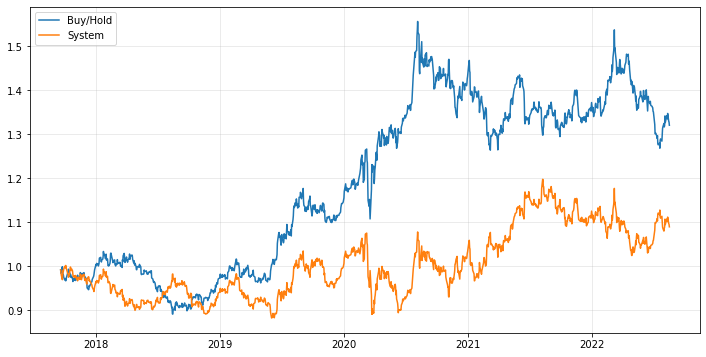

In [ ]:
plt.plot(np.exp(gld['return']).cumprod(), label='Buy/Hold')
plt.plot(np.exp(gld['system_return']).cumprod(), label='System')
plt.legend(loc=2)
plt.grid(True, alpha=.3)

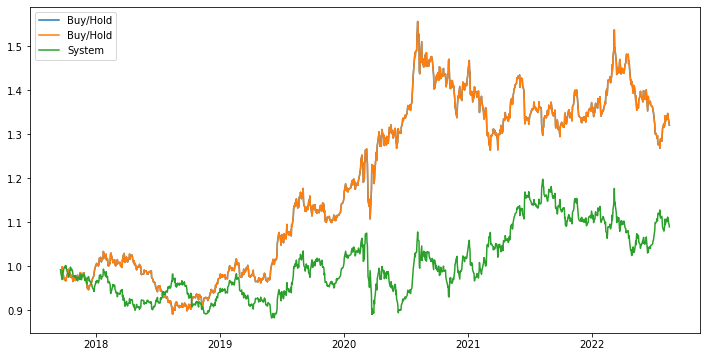

In [ ]:
# using our duplicative columns...
# we get the same things!
# ...be careful of the order of operations!
plt.plot(gld['exp_r_cumprod'], label='Buy/Hold')
plt.plot(gld['exp_s_cumprod'], label='System')
plt.legend(loc=2)
#plt.grid(True, alpha=.3)ChildProcessError

In [ ]:
np.exp(gld['return']).cumprod()[-1] -1

0.3202936931135829

In [ ]:
np.exp(gld['system_return']).cumprod()[-1] -1

0.08972349566505922

As of August 16 2022, if you bought 100k in 2018 - you would have made a ~33% return on your money. If you used your algorithm, you would have achieved a ~9.8% profit... it is tough to find a good algorithm, but some people trade like this!

# Closing Thoughts
* Try to complete all 'on your own' exercises that are in this notebook.
* Try a for loop for all possible numbers between 10 and 300 for short and long and see if you can find an 'optimal' combination of values. Then try it on a few other stocks to see if this really holds true!